## airsim_dataset.py

In [1]:
import os
import json
from PIL import Image
from scipy.ndimage import gaussian_filter

import cv2
import numpy as np
import torch

from vision_process import process_vision_info
from orthography import Orthophoto
from dataset.vis_data import visualize_waypoints


In [2]:
video_frame_num = 5
target_interval = 30
data_list_json_paths = ["../data/train_data_sample.json"]
visualize = False
sigma = 20
visual_prompt = True

data_list = []
for file in data_list_json_paths:
    with open(file, "r") as f:
        datum = json.load(f)
    data_list += datum

data = data_list

ortho_processor = Orthophoto(granularity=0.3)

idx = 7

In [3]:
def preprocess(image, pad_color=(0, 0, 0)):
    img_size = 784
    h, w = image.shape[:2]
    scale = img_size * 1.0 / max(h, w)
    new_h, new_w = h * scale, w * scale
    new_w = int(new_w + 0.5)
    new_h = int(new_h + 0.5)
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    resized_hw = (new_h, new_w)

    pad_h = img_size - new_h
    pad_w = img_size - new_w
    padded_image = cv2.copyMakeBorder(resized_image, 0, pad_h, 0, pad_w,
                                    cv2.BORDER_CONSTANT, value=pad_color)
    return padded_image, resized_hw

def generate_prob_message_v2(pil_image, description):
    visual_prompt = True
    if isinstance(pil_image, np.ndarray):
        pil_image = Image.fromarray(pil_image)
    if isinstance(description, list):
        description = description[0]
    text_parts = description.split("The description of the target and its surrounding is shown below.")
    direction = text_parts[0].strip().split("Compass north corresponds to the top of the bird's-eye-view image.")[-1]
    direction = direction.strip()
    object_description = text_parts[-1].strip()

    prob_message = [{
        'role':'user',
        'content':[
            {'type':'image', 'image':pil_image},
            {'type':'text', 'text': "Task: Predict the probability distribution of the drone's future flight locations to search for the target."
            "Input Image: The image is an orthophoto map generated from the drone's past flight trajectory."},
            {'type':'text', 'text': "The green dots indicate past drone positions." if visual_prompt else " "},
            {'type':'text', 'text': "The top of the image corresponds to the north in the world coordinate system.\n" 
            f"Target Information: {direction}"
            f"The description of the target and its surrounding is shown below: {object_description}\n"
            "Objective: "
            "Analyze the provided orthophoto map and target information."
            "Predict the next flight location for the drone that maximize the probability of finding the target."
            "Output a probability map, indicating the likelihood of different regions in the orthophoto map being the optimal next flight destinations."
            }
        ]
    },
    {
        'role':'assistant',
        'content':[
            {'type':'image', 'image':pil_image}
        ]
    }
    ]
    return prob_message
    
def gaussian(target, img_size):
    sigma = 20
    h, w = img_size
    prob_map = np.zeros((h, w), dtype=np.float32)
    i, j = target
    i, j = min(round(i),h-1), min(round(j),w-1)
    prob_map[i, j] = 1
    i_1 = min(h-1, i+1)
    j_1 = min(w-1, j+1)
    i_2 = max(0, i-1)
    j_2 = max(0, j-1)
    prob_map[i, j_1] = 1
    prob_map[i, j_2] = 1
    prob_map[i_1, j] = 1
    prob_map[i_2, j] = 1

    sigma = max(h,w) // 25 if sigma is None else sigma
    prob_map = gaussian_filter(prob_map, sigma=sigma)
    return prob_map

def get_prob_map(ortho, coor_map, end, ortho_depth=None, delta_height=None):
    h, w = ortho.shape[:2]
    if ortho_depth is not None:
        depth_mask = (ortho_depth > delta_height).reshape(h,w)
    i, j = ortho_processor.world_to_pixel(end, coor_map=coor_map)
    i, j = min(max(round(i), 0), h-1), min(max(round(j), 0), w-1)
    prob_map_0 = np.zeros((h, w))
    prob_map_0[i, j] = 1

    yy, xx = np.ogrid[:h, :w]
    distances = np.sqrt((yy - i)**2 + (xx - j)**2)
    max_dist = np.sqrt(2*(h-1)**2)
    prob_map_0 = 1 - distances / max_dist
    prob_map_0[~depth_mask] = 0

    new_i, new_j = np.unravel_index(np.argmax(prob_map_0), (h, w))
    prob_map = gaussian((new_i, new_j), (h, w))
    # prob_map[~depth_mask] = 0
    prob_map = prob_map / (np.max(prob_map) + 1e-6)

    return prob_map, depth_mask

In [4]:
data_info = data[idx]
traj_dir = data_info["traj_folder_path"]
depth_dir = os.path.join(traj_dir, "bevcamera_depth")
image_dir = os.path.join(traj_dir, "bevcamera")
log_dir = os.path.join(traj_dir, "log")
image_path = data_info["image_path"]

high_uav_pos_now = data_info["high_uav_pos_now"]
end_pos = data_info["end_pos"]
int_time = data_info["int_time"]
target_time = int_time+target_interval

description_path = os.path.join(traj_dir, "object_description_with_help.json")
with open(description_path, 'r') as f:
    description = json.load(f)
description = description[0]

image_files = sorted([f for f in os.listdir(image_dir)])
image_numbers = sorted([int(f.split('.')[0]) for f in image_files])
available_images = [t for t in image_numbers if t <= int_time]
available_num = len(available_images)
if available_num > video_frame_num:
    indices = [round(i * (available_num - 1) / (video_frame_num - 1)) for i in range(video_frame_num)]
    available_images = [available_images[i] for i in indices]
names = [f"{t:06d}" for t in available_images]

# historial orthography
frame_paths = [os.path.join(image_dir, f"{idx}.png") for idx in names]
log_paths = [os.path.join(log_dir, f"{idx}.json") for idx in names]
depth_paths = [os.path.join(depth_dir, f"{idx}.png") for idx in names]
positions = np.array([
            json.load(open(log_path, "r"))["sensors"]["state"]["position"] for log_path in log_paths
            ])
frames = np.array([cv2.imread(frame_path) for frame_path in frame_paths])
depths = np.array([cv2.imread(depth_path, cv2.IMREAD_UNCHANGED) for depth_path in depth_paths])

coord_3d_clouds = ortho_processor.project_images_to_3d(depths, positions)
merged_ortho, coor_map, merged_depth = ortho_processor.orthorectify(frames, coord_3d_clouds, depths)
merged_ortho = cv2.cvtColor(merged_ortho, cv2.COLOR_BGR2RGB)

In [5]:
with open(os.path.join(traj_dir, "gt_waypoints.json"), "r") as f:
    gt_waypoints = json.load(f)
if len(gt_waypoints) > len(image_numbers):
    indices = [round(i * (len(gt_waypoints) - 1) / (len(image_numbers) - 1)) for i in range(len(image_numbers))]
else:
    indices = [i for i in range(len(gt_waypoints))]
index = image_numbers.index(int_time)
time_now = indices[index]
time_target = time_now + target_interval
waypoint_now = gt_waypoints[time_now]
if time_target < len(gt_waypoints):
    waypoint_target = gt_waypoints[time_target]
else:
    waypoint_target = end_pos
if visual_prompt:
    time_indexs = indices[:index]
    vis_waypoints = [gt_waypoints[n] for n in time_indexs]
    merged_ortho_prob = visualize_waypoints(vis_waypoints, coor_map, merged_ortho)
else:
    merged_ortho_prob = merged_ortho
prob_map, depth_mask = get_prob_map(merged_ortho, coor_map, waypoint_target, 
                                    ortho_depth=merged_depth, delta_height=waypoint_now[2]-high_uav_pos_now[2])
ortho_resize_pad, resized_hw = preprocess(merged_ortho_prob)
prob_map, _ = preprocess(prob_map)
depth_mask = depth_mask.astype(np.uint8)
depth_mask, _ = preprocess(depth_mask)
prob_message = generate_prob_message_v2(ortho_resize_pad, description)

prob_map = torch.from_numpy(prob_map)
prob_map = prob_map.unsqueeze(0)

In [6]:
prob_map.shape

torch.Size([1, 784, 784])

In [19]:
ortho_resize_pad.shape

(784, 784, 3)

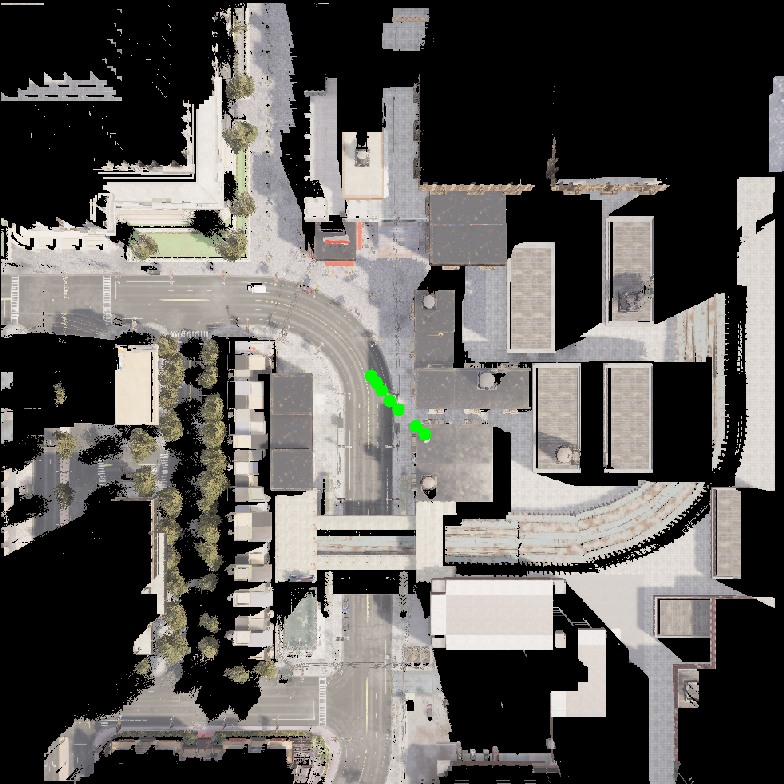

In [20]:
pil_image = Image.fromarray(ortho_resize_pad)
pil_image

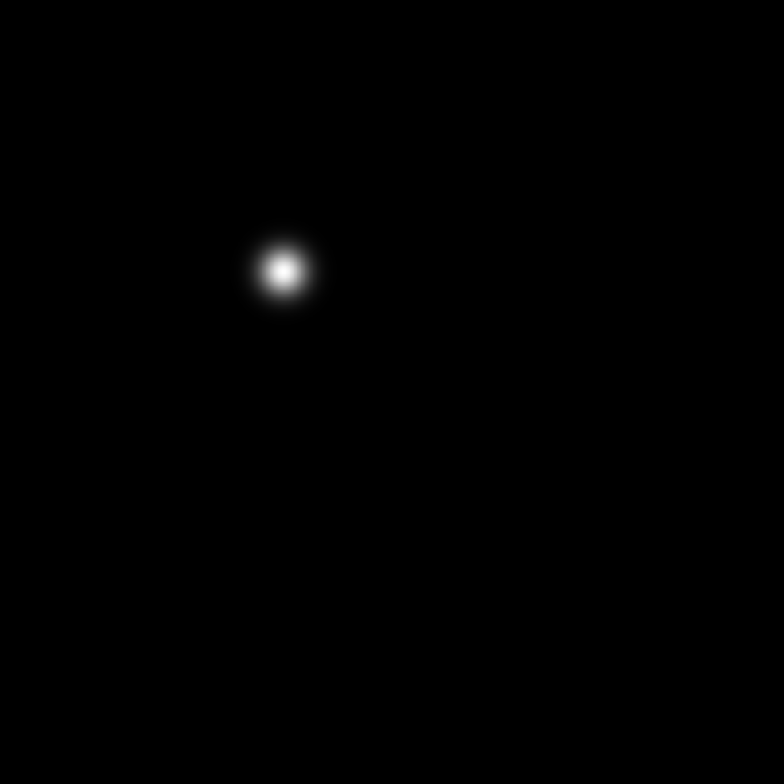

In [26]:
pil_image2 = Image.fromarray((prob_map[0].numpy() * 255).astype('uint8'))
pil_image2

In [24]:
print(prob_map[0].shape)
print(prob_map[0].dtype)
print(prob_map[0].min(), prob_map[0].max())

torch.Size([784, 784])
torch.float32
tensor(0.) tensor(0.9995)


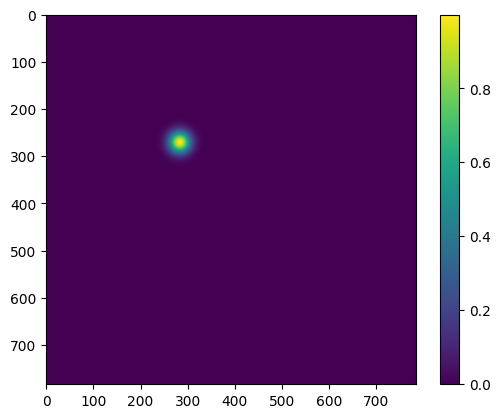

In [25]:
import matplotlib.pyplot as plt
plt.imshow(prob_map[0].squeeze().numpy(), cmap='viridis')
plt.colorbar()
plt.show()

In [12]:
time_now

17

In [13]:
len(gt_waypoints)

39

In [14]:
time_indexs

[0, 2, 5, 7, 10, 12, 14]

In [15]:
waypoint_target

[114.31936645507812, 103.84883880615234, -0.1617560088634491]

In [16]:
len(vis_waypoints)

7

In [17]:
gt_waypoints

[[53.126, 156.814, -17.001],
 [54.15733333333333, 155.72466666666665, -16.997],
 [56.21966666666666, 153.54599999999996, -16.989],
 [58.28233333333333, 151.36733333333333, -16.989],
 [60.34466666666666, 149.18866666666665, -16.989],
 [62.407000000000004, 147.01, -16.989],
 [64.46933333333332, 144.83133333333333, -16.989],
 [65.77962962962962, 143.82362962962964, -16.389],
 [67.08992592592593, 142.81592592592594, -15.789],
 [68.40022222222221, 141.80822222222224, -15.189],
 [69.71051851851851, 140.80051851851854, -14.588999999999999],
 [71.02081481481481, 139.79281481481482, -13.988999999999999],
 [72.33111111111111, 138.78511111111112, -13.389000000000001],
 [73.6414074074074, 137.77740740740742, -12.789],
 [74.9517037037037, 136.76970370370373, -12.189],
 [76.262, 135.76200000000003, -11.589],
 [78.818, 134.19133333333332, -11.589],
 [81.20933333333333, 132.418, -11.589],
 [83.43633333333334, 130.442, -11.589],
 [85.49866666666667, 128.26333333333335, -11.589],
 [87.56099999999999, 12